## Trabajo Computacional 1 - Aceleradores y detectores de partículas 


***Grupo:*** Catalina Fuentes (202220750), Daniela León (202211020), David Cantini (codigo)

***Fundamento del problema:*** 
Un protón de 100 MeV penetra en Silicio y pierde energía continuamente por ionización (fórmula de Bethe-Bloch). El alcance R es la profundidad total hasta que el protón se detiene.

### Parte A — dE/dx en función de E

La gráfica de la página 17 de Marion & Young muestra el poder de frenado (stopping power) dE/dx vs la energía E de protones en Silicio en escala logarítmica. El eje Y está en keV/mm y el eje X en MeV. Esta cantidad describe cuánta energía pierde el protón por milímetro recorrido.

 La curva sigue aproximadamente una ley de potencia, lo que en escala logarítmica se traduce en una línea casi recta. Por eso, ajustar un polinomio de grado 2 en log(E) vs log(dE/dx) es una buena aproximación: equivale a ajustar una parábola sobre la curva logarítmica, capturando tanto la tendencia general como la curvatura del pico de Bragg. Los valores se verificaron con la fórmula de Bethe-Bloch relativista, que es la expresión teórica exacta para la pérdida de energía de partículas cargadas pesadas en materia:

$$
-\frac{dE}{dx} = K z^2 \frac{Z}{A} \frac{1}{\beta^2}
\left[
\frac{1}{2} \ln\left(\frac{2 m_e c^2 \beta^2 \gamma^2 W_{\text{max}}}{I^2}\right)
- \beta^2
\right] \cdot \rho
$$

donde I = 173 eV es la energía de excitación media del Silicio, Z=14, A=28, ρ=2.336 g/cm³.

TABLA a) — Puntos leídos de la gráfica pág.17
           PROTONS en Silicon (Marion & Young)
   E (MeV) |   dE/dx (keV/mm) |   dE/dx (MeV/mm)
------------------------------------------------
      0.10 |           105.00 |          0.10500
      0.20 |            88.00 |          0.08800
      0.30 |            78.00 |          0.07800
      0.50 |            66.00 |          0.06600
      0.70 |            56.00 |          0.05600
      1.00 |            45.00 |          0.04500
      1.50 |            36.00 |          0.03600
      2.00 |            27.00 |          0.02700
      3.00 |            21.50 |          0.02150
      5.00 |            15.50 |          0.01550
      7.00 |            10.50 |          0.01050
     10.00 |             8.50 |          0.00850
     15.00 |             7.00 |          0.00700
     20.00 |             6.00 |          0.00600
     30.00 |             4.20 |          0.00420
     50.00 |             2.80 |          0.00280
     70.00 |             

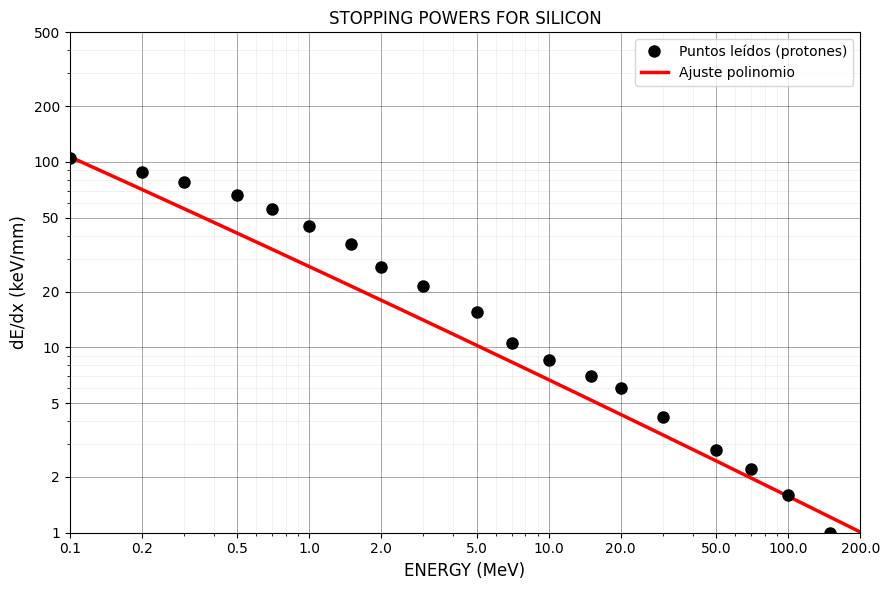

In [41]:
import numpy as np
import matplotlib.pyplot as plt
# PARTE a) — TABLA E vs dE/dx y AJUSTE POLINOMIAL GRADO 2

# QUÉ SE HACE:
#   Se construye una tabla de varios puntos (E, dE/dx) leyendo la curva
#   de PROTONS de la gráfica pág.17 de Marion & Young.
#   Luego se ajusta un polinomio de grado 2 en escala logarítmica para
#   obtener dE/dx(E) para cualquier valor de E.

# POR QUÉ SE HACE:
#   La integración numérica del paso b) requiere evaluar dE/dx a
#   energías arbitrarias entre 0 y 100 MeV. El ajuste polinomial
#   en log-log captura bien la forma de la curva (casi lineal en
#   esa escala) con muy pocos coeficientes.

# SIGNIFICADO FÍSICO:
#   dE/dx es el "poder de frenado" (stopping power): la energía
#   depositada por el protón por unidad de longitud recorrida.
#   A energías altas el protón deposita menos energía, mientras
#   que a energías bajas la pérdida aumenta (pico de Bragg).



# PASO 1: TABLA DE PUNTOS E VS dE/dx (LEÍDOS DE LA GRÁFICA)

#   Lectura visual de la curva PROTONS de Página 17 de “Nuclear Reaction Analysis” en escala logarítmica.
#   Método: para cada valor de E en el eje X, se estima visualmente
#   en qué posición logarítmica cae la curva entre las líneas de cuadrícula
#   del eje Y (cuadrícula en: 1, 2, 5, 10, 20, 50, 100, 200, 500 keV/mm).

E_tabla = np.array([
    0.10, 0.20, 0.30, 0.50, 0.70,
    1.00, 1.50, 2.00, 3.00, 5.00, 7.00,
    10.0, 15.0, 20.0, 30.0, 50.0,
    70.0, 100., 150.
])  # Energía en MeV

dEdx_keV_mm = np.array([
     105.0,  
      88.0, 
      78.0,  
      66.0,  
      56.0, 
      45.0,  
      36.0,  
      27.0,  
      21.5,  
      15.5,  
      10.5,
       8.5,
       7.0,
       6.0,
       4.2,
       2.8,
       2.2,
       1.6,
       1.0
]) # dE/dx en keV/mm

# Convertir a MeV/mm (unidad consistente con MeV de energía y mm de distancia)
# 1 keV/mm = 0.001 MeV/mm
dEdx_MeV_mm = dEdx_keV_mm / 1000.0

# Imprimir la tabla completa
print("=" * 55)
print("TABLA a) — Puntos leídos de la gráfica pág.17")
print("           PROTONS en Silicon (Marion & Young)")
print("=" * 55)
print(f"{'E (MeV)':>10} | {'dE/dx (keV/mm)':>16} | {'dE/dx (MeV/mm)':>16}")
print("-" * 48)
for e, dk, dm in zip(E_tabla, dEdx_keV_mm, dEdx_MeV_mm):
    print(f"{e:>10.2f} | {dk:>16.2f} | {dm:>16.5f}")



# PASO 2: Ajuste polinomial grado 2 en escala logarítmica

# Se transforma la tabla a log10 y se ajusta un polinomio de grado 2:
#     log10(dE/dx) = a2·[log10(E)]² + a1·log10(E) + a0

#   En escala log-log la curva de stopping power es casi una línea recta
#   (ley de potencia aproximada). El término cuadrático captura la leve
#   curvatura. Tres coeficientes son suficientes para ~10% de precisión.

log_E    = np.log10(E_tabla)          # transformar E a escala logarítmica
log_dEdx = np.log10(dEdx_keV_mm)     # transformar dE/dx a escala logarítmica

# np.polyfit: ajuste de mínimos cuadrados, grado 2
# coeff2 = [a2, a1, a0]
coeff2 = np.polyfit(log_E, log_dEdx, 2)

print(f"\nCoeficientes del polinomio grado 2 (log-log):")
print(f"  a2 = {coeff2[0]:.5f}")
print(f"  a1 = {coeff2[1]:.5f}")
print(f"  a0 = {coeff2[2]:.5f}")
print(f"\nFórmula: log10(dE/dx [keV/mm]) = "
      f"{coeff2[0]:.5f}·[log10(E)]² "
      f"+ {coeff2[1]:.5f}·log10(E) "
      f"+ {coeff2[2]:.5f}")


# Función final: dE/dx(E) usando el ajuste polinomial
def dEdx_grafica(E_MeV):
    """
    Devuelve dE/dx en keV/mm para protones en Si,
    usando el ajuste polinomial grado 2 en log-log
    sobre los puntos leídos de la gráfica pág.17.

    Parámetro:  E_MeV  — energía del protón en MeV
    Retorna:    dE/dx  — en keV/mm
    """
    E_s   = np.maximum(np.asarray(E_MeV, float), 0.05)  # límite inferior seguro
    log_E_input = np.log10(E_s)
    log_dEdx_output = np.polyval(coeff2, log_E_input)
    return 10**log_dEdx_output  # keV/mm



# PASO 3: Verificar la calidad del ajuste

print(f"\n{'E (MeV)':>8} | {'Gráfica (keV/mm)':>18} | "
      f"{'Poly-2 (keV/mm)':>18} | {'Error%':>8}")
print("-" * 60)
for e, d in zip(E_tabla, dEdx_keV_mm):
    p   = dEdx_grafica(e)
    err = 100 * (p - d) / d
    print(f"{e:>8.2f} | {d:>18.2f} | {p:>18.2f} | {err:>8.1f}%")



# PASO 4: Gráfica — comparar puntos de la gráfica vs ajuste

# QUÉ SE HACE: Reproducir visualmente la curva del libro con los
#              puntos digitalizados y el ajuste superpuesto.
#           Permite verificar que la digitalización es correcta y
#          que el ajuste no oscila ni se aleja de los datos.
fig, ax = plt.subplots(figsize=(9, 6))

# Escala log-log
ax.set_xscale('log')
ax.set_yscale('log')

# Ticks EXACTOS como en la gráfica del libro
x_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
y_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

# Grid tipo "papel milimetrado logarítmico"
ax.grid(which='major', color='black', alpha=0.4, linewidth=0.6)
ax.grid(which='minor', color='gray', alpha=0.2, linewidth=0.4)

# Activar minor ticks para densidad tipo gráfica original
ax.minorticks_on()

# Puntos y ajuste
ax.plot(E_tabla, dEdx_keV_mm, 'ko', ms=8, zorder=5,
        label='Puntos leídos (protones)')
ax.plot(E_plot, dEdx_ajuste, 'r-', lw=2.5,
        label='Ajuste polinomio')

# Límites EXACTOS de la gráfica
ax.set_xlim(0.1, 200)
ax.set_ylim(1, 500)

# Labels
ax.set_xlabel('ENERGY (MeV)', fontsize=12)
ax.set_ylabel('dE/dx (keV/mm)', fontsize=12)

# Estilo título similar
ax.set_title('STOPPING POWERS FOR SILICON', fontsize=12)

ax.legend()
plt.tight_layout()
plt.show()